# Code-Übung 4: Finite-Elemente-Methode
Themen dieser Übung sind:
 - Herleiten der schwachen Form
 - Anwenden der Ritz-Galerkin-Diskretisierung
    - Bilineare Q4 Formfunktionen
 - Koordinatentransformation
    - Integral- und Gradiententransformation
    - Aufstellen der Jacobi-Matrix
 - Randbedingungen (Neumann/ Dirichlet)
 - Assemblierung

In [22]:
import numpy as np

In dieser Vorrechenübung wird ein letztes Mal das Beispiel einer zweidimensionalen Wärmeleitung behandelt. Gegeben ist das folgende Gebiet mit einer Wärmequelle in der Mitte:

<p align=center><img src="./graphics/heat_source.png" style="width: 30%;"></p>

## Modellparameter

In [23]:
# Model parameters
L_x = 1.0                   # x dimension of the plate in m
L_y = 1.0                   # y dimension of the plate in m
rho = 10.0                 # Density of the medium (here: water) in kg/m^3
c_p  = 10.0                 # heat capacity in J/(kg K)
lambd = 1.0                 # thermal conductivity in W/(m K)
alpha = lambd/(rho*c_p)     # thermal diffusivity in m^2/s
v_1 = 0.0                     # x speed in m/s
v_2 = 0.0                     # y speed in m/s
u = np.array([v_1, v_2])    # velocity vector

# Grid parameters
N_x = 50                    # Nodes in x direction
N_y = 50                    # Nodes in y direction
delta_x = L_x/(N_x-1)       # Step size in x direction in m
delta_y = L_y/(N_y-1)       # Step size in y direction in m
n_elements = (N_x-1) * (N_y-1)  # Number of elements in the grid


## Schwache Form
Die stationäre Konvektions-Diffusions-Gleichung wird in Operatorenschreibweise verwendet:
$$
 \rho c_p \boldsymbol{u} \nabla \phi - k  \Delta \phi = Q
$$

Davon ausgehend wird die schwache Form der Gleichung hergeleitet. Hierfür wird die Gleichung mit einer Testfunktion $\omega$ multipliziert und der Satz von Gauß angewandt, sodass die zweiten Ableitungen nicht mehr in der Gleichung auftreten:
$$
\int _\Omega \omega \cdot (\rho c_p \boldsymbol{u} \nabla \phi - k \Delta \phi) d\Omega = \int _\Omega \omega Q d\Omega \\
\int _\Omega \omega \cdot (\rho c_p \boldsymbol{u} \nabla \phi) d\Omega + \int _\Omega \nabla \omega (k \cdot \nabla \phi) d\Omega  - \int _{\Gamma_\Omega} \omega \cdot k \nabla \phi \boldsymbol{ds}= \int _\Omega \omega Q d\Omega \\ 
$$

Das Randintegral $\int _{\Gamma_\Omega} \omega \cdot k \nabla \phi \boldsymbol{ds}$ wird zunächst veranchlässigt und im Rahmen der Randbedingungen wieder aufgegriffen.

## Ritz-Galerkin-Diskretisierung
Nun wird für jedes Element ein Ansatz für die Funktion $\phi$ gemacht. Pro Element $e$ werden $j=4$ Formfunktionen $N$ benötigt. Der Galerkin-Ansatz besagt, dass für die Testfunktion $\omega$ die selben Formfunktionen $N$ genutzt werden. Für den Rest des Abschnitts wird immer nur genau ein Element betrachtet. Der Übergang zur globalen Betrachtung findet im Abschnitt "Assemblierung" statt:
 $$
\phi^e(x, y) = \sum_{j=1}^{4} \phi_j^e \cdot N_j ^e (x, y) \\
\omega^e(x, y) = \sum_{i=1}^{4} \omega_i^e \cdot N_i ^e (x, y)
 $$

<p align=center><img src="./graphics/Diskretisierung.png" style="width: 40%;"></p>

*Beachte*: Bei der FEM wird der Wert der Funktion an den Knoten des Elements bestimmt. In diesem Fall sind dies die vier Ecken des Elementes.

Die Ansätze für $\phi$ und $\omega$ werden nun in die schwache Form eingesetzt:
$$
\begin{align*}
&\int _\Omega \sum_{i=1}^{4} \omega_i^e \cdot N_i ^e (x, y) \cdot (\rho c_p \boldsymbol{u} \nabla \sum_{j=1}^{4} \phi_j^e \cdot N_j ^e (x, y)) d\Omega\\
+ &\int _\Omega \nabla \sum_{i=1}^{4} \omega_i^e \cdot N_i ^e (x, y) \cdot k \cdot (\nabla (\sum_{j=1}^{4} \phi_j^e \cdot N_j ^e (x, y)))^T d\Omega\\
= &\int _\Omega \sum_{i=1}^{4} \omega_i^e \cdot N_i ^e (x, y) Q d\Omega 
\end{align*}
$$

Nach Eliminieren der Summe über $\omega_i$ und Ausklammern von $\phi_i$ führt auf das LGS:
$$
\boldsymbol{K\cdot\phi = b}
$$

Für die Terme $K_{ij}, b_i$ folgt (betrachte hier festes $i$):
$$
\begin{align*}
&\sum_{j=1}^{4} \int _\Omega N_i ^e (x, y) \cdot (\rho c_p \boldsymbol{u} \nabla \phi_j^e \cdot N_j ^e (x, y)) d\Omega\\
 + &\int _\Omega \nabla N_i ^e (x, y) \cdot k \cdot (\nabla \phi_j^e \cdot N_j ^e (x, y))^T d\Omega\\
 = &\int _\Omega N_i ^e (x, y) Q d\Omega
\end{align*}
$$
bzw. mit ausgeklammertem $\phi_j$
$$
\sum_{j=1}^{4} \underbrace{\int _\Omega N_i ^e \cdot (\rho c_p v_i \nabla N_j ^e) + \nabla N_i ^e \cdot k \cdot (\nabla N_j ^e)^T d\Omega}_{K_{ij}^e}  \cdot \phi_j^e = \underbrace{\int _\Omega N_i ^e Q d\Omega}_{b_i}
$$

Es werden Q4-Elemente mit den folgenden lokalen Formfunktionen mit $\xi_1, \xi_2 \in [-1, 1]^2$ gewählt. Die Transformation auf $[-1, 1]^2$ hat den Vorteil, dass die in $K_{ij}$ auftretenden Integrale effizient mittels Gauß-Quadratur gelöst werden können:

$$
    N_1^e(\xi_1, \xi_2) = \frac{1}{4}(1-\xi_1)(1-\xi_2)\\
    N_2^e(\xi_1, \xi_2) = \frac{1}{4}(1+\xi_1)(1-\xi_2)\\
    N_3^e(\xi_1, \xi_2) = \frac{1}{4}(1+\xi_1)(1+\xi_2)\\
    N_4^e(\xi_1, \xi_2) = \frac{1}{4}(1-\xi_1)(1+\xi_2)
$$

<p align=center><img src="./graphics/Formfunktionen.png" style="width: 30%;"></p>

## Koordinatentransformation
Um diese Formfunktionen nutzen zu können, müssen jedoch die Steifigkeitsmatrix $K^e$, und der Lastvektor $b^e$ in lokale Koordinaten transformiert werden. Hierfür wird die isoparametrische Koordinatentransformation genutzt (Gitter $\Omega_h \rightarrow \hat{\Omega}$ Referenzgebiet) mit der allgemeinen Formel:
$$
\boldsymbol{x}^e_h =  \sum{N^e_i(\xi)\cdot\boldsymbol{x^e_i}}
$$
Hier gelten ferner die allgemeinen Formeln:
$$
d \Omega = \boldsymbol{dx} = \det (\frac{d\boldsymbol{x}}{d \boldsymbol{\xi}})\boldsymbol{d\xi} = \det \boldsymbol{Jd\xi} \\
\nabla N_i^e = \nabla_\xi N_i^e\cdot \boldsymbol{J^{-1}}
$$

mit der Jacobi-Matrix $J$:
$$
\boldsymbol{J(\xi)} = 
        \begin{bmatrix}
            x_1^e & x_2^e & x_3^e & x_4^e\\
            y_1^e & y_2^e & y_3^e & y_4^e
        \end{bmatrix}
        \cdot
        \begin{bmatrix}
            \partial_{\xi_1}N_1^e & \partial_{\xi_2}N_1^e \\
            \partial_{\xi_1}N_2^e & \partial_{\xi_2}N_2^e \\
            \partial_{\xi_1}N_3^e & \partial_{\xi_2}N_3^e \\
            \partial_{\xi_1}N_4^e & \partial_{\xi_2}N_4^e
        \end{bmatrix}
$$
Wobei 
$$
\begin{bmatrix}
            x_1^e & x_2^e & x_3^e & x_4^e\\
            y_1^e & y_2^e & y_3^e & y_4^e
        \end{bmatrix}
$$
die Koordinatenmatrix des Elements ist (s. Abschnitt Assemblierung).

Durch Einsetzen folgt:
$$
K_{ij}^e = \int _{e_i} N_i ^e \cdot (\rho c_p \boldsymbol{u} \nabla _\xi N_j ^e \cdot \boldsymbol{J^{-1}}) + \nabla_\xi N_i ^e \cdot \boldsymbol{J^{-1}} \cdot k \cdot (\nabla_\xi N_j ^e \cdot \boldsymbol{J^{-1}})^T \det \boldsymbol{Jd\xi}
$$

Eine analoge Überlegung ergibt für $b_i$:
$$
b_i^e = \int_{e_i} N_i^e \cdot Q \det(\boldsymbol{J})\boldsymbol{d \xi}
$$

In [24]:
# Define the shape functions
N_1 = lambda xi1, xi2: 0.25 * (1 - xi1) * (1 - xi2)
N_2 = lambda xi1, xi2: 0.25 * (1 + xi1) * (1 - xi2)
N_3 = lambda xi1, xi2: 0.25 * (1 + xi1) * (1 + xi2)
N_4 = lambda xi1, xi2: 0.25 * (1 - xi1) * (1 + xi2)

N = [N_1, N_2, N_3, N_4]

# Define the derivatives of the shape functions
grad_N_1 = lambda xi1, xi2: np.array([-0.25 * (1 - xi2), -0.25 * (1 - xi1)])
grad_N_2 = lambda xi1, xi2: np.array([0.25 * (1 - xi2), -0.25 * (1 + xi1)])
grad_N_3 = lambda xi1, xi2: np.array([0.25 * (1 + xi2), 0.25 * (1 + xi1)])
grad_N_4 = lambda xi1, xi2: np.array([-0.25 * (1 + xi2), 0.25 * (1 - xi1)])

grad_N = [grad_N_1, grad_N_2, grad_N_3, grad_N_4]

# Define the Jacobian matrix for the transformation from the reference element to the physical element
def jacobian(xi1, xi2, x_coords, y_coords):
    J = np.zeros((2, 2))
    for i in range(4):
        grad_N_i = grad_N[i](xi1, xi2)
        J[0, 0] += grad_N_i[0] * x_coords[i]
        J[0, 1] += grad_N_i[0] * y_coords[i]
        J[1, 0] += grad_N_i[1] * x_coords[i]
        J[1, 1] += grad_N_i[1] * y_coords[i]
    return J

# Define the quadrature points and weights for Gauss quadrature
gauss_points = [(-1/np.sqrt(3), -1/np.sqrt(3)),
                (1/np.sqrt(3), -1/np.sqrt(3)),
                (1/np.sqrt(3), 1/np.sqrt(3)),
                (-1/np.sqrt(3), 1/np.sqrt(3))]
gauss_weights = [1, 1, 1, 1]

# Formula for K_ij. Use Gauss quadrature to evaluate the integral over the element.
def k_ij(i, j, x_coords, y_coords):
    K = 0
    for (xi1, xi2), weight in zip(gauss_points, gauss_weights): # Integration over the element using Gauss quadrature
        J = jacobian(xi1, xi2, x_coords, y_coords)
        det_J = np.linalg.det(J)
        inv_J = np.linalg.inv(J)
        grad_N_i = grad_N[i](xi1, xi2)
        grad_N_j = grad_N[j](xi1, xi2)
        N_i = N[i](xi1, xi2)

        K += weight *(N_i * (rho *c_p * u @ (grad_N_j @ inv_J)) + lambd * (grad_N_i @ inv_J) @ (grad_N_j @ inv_J).T) * det_J
    return K

# Define element stiffness matrix K^e
def K_e(x_coords, y_coords):
    K_e = np.zeros((4, 4))
    for i in range(4):
        for j in range(4):
            K_e[i, j] = k_ij(i, j, x_coords, y_coords)
    return K_e

# Define the heat source (here: a square in the middle of the plate, continuous function)
def heat_source(x, y):
    source_size = 0.2 # size of the heat source in m
    Q_0 = 1000
    if (L_x/2 - source_size/2 <= x <= L_x/2 + source_size/2) and (L_y/2 - source_size/2 <= y <= L_y/2 + source_size/2):
        return Q_0
    else:
        return 0

# Define the element load vector b^e
def b_e(x_coords, y_coords):
    b_e = np.zeros(4)
    for i in range(4):
        for (xi1, xi2), weight in zip(gauss_points, gauss_weights): # Integration over the element using Gauss quadrature
            J = jacobian(xi1, xi2, x_coords, y_coords)
            det_J = np.linalg.det(J)
            N_i = N[i](xi1, xi2)

            # Get the load associated with the current element
            # Convert from (xi1, xi2) to (x, y) coordinates
            x_h = x_coords @ np.array([N_1(xi1, xi2), N_2(xi1, xi2), N_3(xi1, xi2), N_4(xi1, xi2)])
            y_h = y_coords @ np.array([N_1(xi1, xi2), N_2(xi1, xi2), N_3(xi1, xi2), N_4(xi1, xi2)])
            Q = heat_source(x_h, y_h)

            b_e[i] += weight * N_i * Q * det_J
    return b_e

## Neumann-Randbedingungen
Hier wird zunächst das Randintegral von oben betrachetet: $\int _{\Gamma_\Omega} \omega \cdot k \nabla \phi \boldsymbol{dS}$. Es wird angenommen, dass der Rand $\Gamma_\Omega$ aus einem Teil $\Gamma_N$ mit Neumann-Randbedingungen und einem Teil  $\Gamma_D$ mit Dirichlet-Randbedingungen besteht. Das Randintegral lässt sich dann aufteilen 
$$
\int _{\Gamma_\Omega} \omega \cdot k \nabla \phi \boldsymbol{ds} = \int _{\Gamma_N} \omega \cdot k \nabla \phi \boldsymbol{ds} + \int _{\Gamma_D} \omega \cdot k \nabla \phi \boldsymbol{ds}
$$
Für eine Dirichlet-Randbedingung gilt $\phi \vert _w = T_w$ und damit $\frac{\partial \phi}{\partial x_1} \vert _w = 0$. Das Randintegral kann daher vereinfacht werden zu:
$$
\int _{\Gamma_\Omega} \omega \cdot k \nabla \phi \boldsymbol{ds} = \int _{\Gamma_N} \omega \cdot k \nabla \phi \boldsymbol{ds}
$$
bzw. mit Galerkin-Diskretisierung
$$
\int _{\Gamma_\Omega} \omega \cdot k \nabla \phi \boldsymbol{ds} = \int _{\Gamma_N} \sum_{i=1}^{4} \omega_i^e \cdot N_i ^e (x, y) \cdot k \nabla \phi \boldsymbol{ds}
$$
Einsetzen und Transformation auf das Referenzgebiet
$$
\hat{b_i^e} = \int _{\Gamma_N} N_i ^e \cdot q_i \boldsymbol{ds}
$$
Es ist ersichtlich, dass Neumann-Randbedingungen über das Randintegral in das Problem integriert werden können. In der Anwendung geht dies am einfachsten durch Aufaddieren der Neumann-Terme auf den Lastvektor $\boldsymbol{b}$.
$$
\boldsymbol{b_i^e = \hat{b_i^e} + \bar{b_i^e}}
$$
Dabei ist $\bar{b_i^e}$ das Ergebnis aus dem Lastvektor und $\hat{b_i^e}$ der Zusatzanteil aus den Neumann-Randbedingungen.


In [25]:
# bc-order: west, east, south, north
bc_types = ["dirichlet", "neumann", "neumann", "dirichlet"]
T = [300, 300, 300, 300]
q = [0, 0, 0, 0]

# Define the nodes that belong to each boundary
south_nodes = [j*N_y for j in range(N_x)]
west_nodes = [j for j in range(N_y)]
east_nodes = [N_x*N_y - j - 1 for j in range(N_y)]
north_nodes = [j*N_y + N_y-1 for j in range(N_x)]

# Define the Gauss points and weights for 1D integration (used for Neumann BCs)
gauss_points_1d = [-1/np.sqrt(3), 1/np.sqrt(3)]
gauss_weights_1d = [1, 1]

# Define the element load vector b^e for Neumann BCs
def b_e_neumann(element):
    b_e_n = np.zeros(4)

    for idx, node in enumerate(element):
        for (xi1, xi2), weight in zip(gauss_points, gauss_weights): # Iteratively apply the Gauss quadrature for each node in the element
            N_i = N[idx](xi1, xi2)

            if node in south_nodes and bc_types[2] == "neumann":
                b_e_n[idx] += weight * N_i * q[2]
            
            if node in west_nodes and bc_types[0] == "neumann":
                b_e_n[idx] += weight * N_i * q[0]
            
            if node in east_nodes and bc_types[1] == "neumann":
                b_e_n[idx] += weight * N_i * q[1]
            
            if node in north_nodes and bc_types[3] == "neumann":
                b_e_n[idx] += weight * N_i * q[3]

    return b_e_n

## Assemblierung

Die Assemblierung ist der Übergang von der Betrachtung einzelner Elemente zur Betrachtung des gesamten Gebiets. Hierfür muss jedoch zunnächst das Netz definiert werden. Dies geht formal über die Koinzidenzmatrix $\mathbb{E}_h$, welche die Position der Elemente relativ zueinander festlegt, sowie die Koordinatenmatrix $\mathbb{X}_h$, welche die Koordinaten der Knotenpunkte enthält.

Jede Spalte der Koinzidenzmatrix beschreibt ein Element. Die Zeilen der Spalte enthalten die globalen Indizes der Knotenpunkte, die das Element umschließen. Die Koordinatenmatrix besteht aus zwei Zeilen, wobei die erste Zeile die x-Werte und die zweite Zeile alle y-Werte der Knoten enthält.

Bei der Assemblierung werden die Elementsteifigkeitsmatrizen und Elementlastvektoren in eine Gesamtsteifigkeitsmatrix und einen Gesamtsteifigkeitsvektor kombiniert. Für die Assemblierung werden die Koinzidenzmatrix und die Koordinatenmatrix benötigt.

In [26]:
# Define the element connectivity matrix E_h
E_h = np.zeros((4, n_elements))

for element_col in range(N_x - 1):      # element column
    for element_row in range(N_y - 1):  # element row

        element_index = element_col*(N_y-1) + element_row

        n1 = element_col*N_y + element_row
        n2 = (element_col+1)*N_y + element_row
        n3 = (element_col+1)*N_y + element_row + 1
        n4 = element_col*N_y + element_row + 1

        E_h[:, element_index] = [n1, n2, n3, n4]

# Define the node coordinates matrix X_h
X_h = np.zeros((2, N_x*N_y))
for i in range(N_x):
    for j in range(N_y):
        idx = i*N_y + j
        X_h[0, idx] = i*delta_x
        X_h[1, idx] = j*delta_y

# Initialize the global stiffness matrix K and load vector b
K = np.zeros((N_x*N_y, N_x*N_y))
b = np.zeros(N_x*N_y)

# Element load vector and stiffness matrix -> global load vector and stiffness matrix
for element_idx in range(E_h.shape[1]):
    # Get the coordinates of the nodes of the current element
    x_coords = np.zeros(4)
    y_coords = np.zeros(4)

    element = E_h[:, element_idx]

    for idx, node in enumerate(element):
        x_coords[idx] = X_h[0, int(node)]
        y_coords[idx] = X_h[1, int(node)]

    # Compute the element stiffness matrix and load vector
    K_element = K_e(x_coords, y_coords)
    b_element = b_e(x_coords, y_coords)
    b_neumann = b_e_neumann(element)

    # Assemble the global stiffness matrix and load vector
    for i in range(4):
        global_i = int(element[i])
        b[global_i] += b_element[i] + b_neumann[i]
        for j in range(4):
            global_j = int(element[j])
            K[global_i, global_j] += K_element[i, j]


## Dirichlet-Randbedingungen
Die Dirichlet-Randbedingungen $\phi \vert _w = T_w$ geben feste Werte für einzelne $\phi_j$. Die bekannten Werte werden dort, wo Dirichlet-Randbedingungen vorgegeben sind in das LGS eingesetzt und das LGS wird umgeformt, indem der Lastvektor b aktualisiert wird. Wenn der Wert $\phi_j$ gegeben ist, muss zudem die Zeile $j$ geändert werden. Der Eintrag $K_{jj} = 1$ wird angepasst, während alles anderen Einträge der Zeile $j$ gleich null gesetzt werden.

In [27]:
# South boundary
if bc_types[2] == "dirichlet":
    for idx, node in enumerate(south_nodes):
        # Get col associated with the node from stiffness matrix K
        col = K[:, node]
        b -= T[2] * col
        
        # Update the stiffjness matrix K
        K[node, :] = 0
        K[:, node] = 0
        K[node, node] = 1.0

        # Update the load vector b
        b[node] = T[2]

# West boundary
if bc_types[0] == "dirichlet":
    for idx, node in enumerate(west_nodes):
        # Get col associated with the node from stiffness matrix K
        col = K[:, node]
        b -= T[0] * col
        
        # Update the stiffjness matrix K
        K[node, :] = 0
        K[:, node] = 0
        K[node, node] = 1.0

        # Update the load vector b
        b[node] = T[0]

# East boundary
if bc_types[1] == "dirichlet":
    for idx, node in enumerate(east_nodes):
        # Get col associated with the node from stiffness matrix K
        col = K[:, node]
        b -= T[1] * col
        
        # Update the stiffjness matrix K
        K[node, :] = 0
        K[:, node] = 0
        K[node, node] = 1.0

        # Update the load vector b
        b[node] = T[1]

# North boundary
if bc_types[3] == "dirichlet":
    for idx, node in enumerate(north_nodes):
        # Get col associated with the node from stiffness matrix K
        col = K[:, node]
        b -= T[3] * col
        
        # Update the stiffjness matrix K
        K[node, :] = 0
        K[:, node] = 0
        K[node, node] = 1.0

        # Update the load vector b
        b[node] = T[3]

## Visualisieren der Ergebnisse

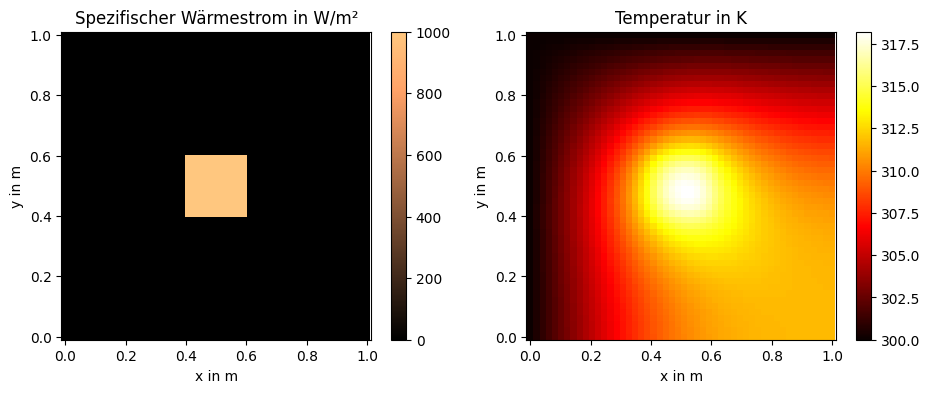

In [28]:
from helper_functions import plot_heat

# Solve the system
Phi = np.linalg.solve(K, b)

# Reshape to grid
Phi = Phi.reshape((N_y, N_x), order='F')

# Plot the temperature field
x = np.linspace(0, L_x, N_x)
y = np.linspace(0, L_y, N_y)
X, Y = np.meshgrid(x, y)

Z = [[heat_source(x1, y1) for x1 in x] for y1 in y]

# Auswerten
plot_heat(Z, X, Y, Phi)